Riccardo Lorenzon - Head of Data @Vedrai 

riccardo.lorenzon@vedrai.com

# Introduction to Machine Learning Models

## What is a Machine Learning model?

$y = f(x)$ is the most general form of mathematical relationship between an input $x$ and an output $y$. We call our approximation of $f$ an Estimator

We want to estimate $f$ in "the most accurate way" starting from available data thanks to a model which "learns" the underlying mathematical relationship (fit).

Knowledge of $f$ is mainly used for prediction of $y$ for a specific $x$ which we have not seen in the orginal dataset (predict).

## Regression or classification?

We talk about **regression** when $y$ is a real value or vector. 

We talk about **classification** when $y$ is a categorical value or vector.

## What is Linear Regression?

Linear regression is one of the simplest and most commonly used machine learning algorithms. **It tries to find a straight line that best fits your data, which can then be used to make predictions**. 

$y = a + b*x$

* y  è la **variabile dipendente** (output o target)

* x  è la **variabile indipendente** (input o feature)

* a  è l’**intercetta** (intercept), cioè il valore di  y  quando  x = 0 

* b  è il **coefficiente angolare** (slope), che rappresenta quanto varia  y  al variare di  x


<img src="linear-reg.jpeg" width=400>

**🔹 Significato dei parametri**

1. **Intercetta**  `a`
* È il punto in cui la retta di regressione interseca l’asse  y  (quando  x = 0 ).

* Indica il valore di  y  che il modello predirebbe in assenza di effetti della variabile  x .

* Se  a = 5 , allora quando  x = 0 , il valore previsto di  y  sarà 5.

2. **Coefficiente angolare**  `b` 
* Indica quanto aumenta (o diminuisce)  y  per ogni unità di incremento di  x .

* Se  b = 2 , significa che **ad ogni aumento di 1 unità di**  x **,**  y  **cresce di 2**.

* Se  b  è negativo, allora  y  diminuisce all’aumentare di  x .

## Step 1: Import the necessary libraries

First, we need to import the Python libraries that will help us work with data and build our model.

In [81]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix

## Step 2: Create or load a dataset

For this tutorial, we'll create a simple dataset about house sizes and prices. In real projects, you would typically load data from a file or database (in our case titanic.csv).

In [113]:
# Create a sample dataset (house size in square feet and price in thousands of dollars)
np.random.seed(42)  # For reproducible results
n_samples = 200
task = 'regression'
# task = 'classification' # regression
# House sizes between 1000 and 3000 square feet
house_sizes = np.random.randint(1000, 3000, n_samples)

# House prices with some relationship to size plus random noise
house_prices = 100 + 0.2 * house_sizes - 0.00003 * house_sizes**2 + np.random.normal(0, 50, n_samples)

# Create a DataFrame
data = pd.DataFrame({
    'Size': house_sizes,
    'Price': house_prices
})

# Display the first 5 rows of the dataset
data.head()

,Size,Price
0,2126,394.191759
1,2459,311.021124
2,1860,357.228406
3,2294,418.782549
4,2130,463.787702


In [100]:
# Or we load our most beloved dataset (maybe we use it later)

titanic = pd.read_csv('../lecture_1/data/titanic.csv')

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
if task == 'classification':
    data = titanic.copy()
    data = data[['Survived','Age']]
    

data.head(9)

,Size,Price
0,2126,394.191759
1,2459,311.021124
2,1860,357.228406
3,2294,418.782549
4,2130,463.787702
5,2095,361.415739
6,2724,381.770040
7,2044,358.374068
8,2638,464.598786


## Step 3: Visualize the data

It's important to visualize your data to understand the relationship between variables before building a model.

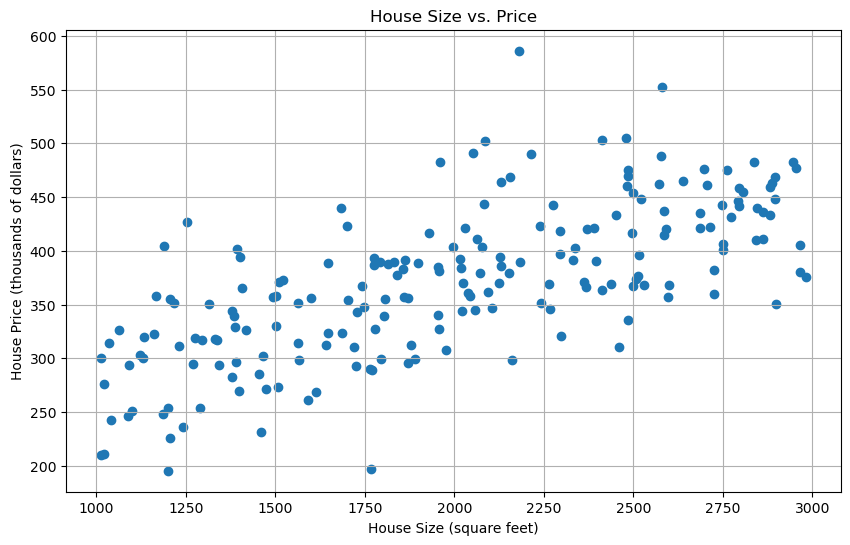

In [115]:
# Create a scatter plot of house size vs. price

xxx = data['Size'] if task=='regression' else data['Age']
yyy = data['Price'] if task=='regression' else data['Survived']

plt.figure(figsize=(10, 6))
plt.scatter(xxx, yyy)
plt.title('House Size vs. Price')
plt.xlabel('House Size (square feet)')
plt.ylabel('House Price (thousands of dollars)')
plt.grid(True)
plt.show()

[Simpson's Paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox)

Il **paradosso di Simpson** è un fenomeno statistico in cui **una tendenza osservata in diverse gruppi di dati può invertire o scomparire quando i dati vengono aggregati**. In altre parole, l’effetto che sembra emergere da singoli gruppi potrebbe risultare completamente diverso quando i gruppi vengono combinati, a causa di variabili confondenti non considerate inizialmente.

👆🏻 **mi rompe il flow** 😝

<img src="disneytoons-movies.gif" width="450" align="center">


## Step 4: Split the data into training and testing sets

Before training our model, we need to split our data into:
- **Training set**: Used to train the model
- **Testing set**: Used to evaluate how well the model performs on new, unseen data

Why?

We need to ensure our model **generalizes** enough, meaning it does not learn the specific structure of the training set, but rather learns the underlying structure of $f$

### Densità dei dati vs sparsità dei dati
La **densità dei dati** indica **quanto sono vicini i punti di un dataset in uno spazio di caratteristiche (feature space)**.
> - Se i dati sono **densi**, significa che i punti sono **ben distribuiti e vicini tra loro**.
> - Se i dati sono **sparsi (sparse)**, significa che ci sono **molti spazi vuoti tra i punti**.
> 🔥 **Esempio:**
> - Se analizziamo **l’altezza delle persone in un dataset con 1.000 individui**, i valori saranno **concentrati in un certo intervallo (150-200 cm)** → **alta densità**.
> - Se invece analizziamo **un dataset con 1.000 aziende e 10.000 caratteristiche (features)**, molte feature avranno **zero o valori mancanti** → **bassa densità (sparsità)**.

La **sparsità** è l’opposto della densità e si verifica quando **molti valori in un dataset sono zero o mancanti**.
> 
>   
> 
> ✅ **Dove si trova la sparsità?**
> 
> • **Dati testuali:** La maggior parte delle parole di un dizionario **non appare in un singolo documento** → i dati sono **sparse**.
> 
> • **Dati di raccomandazione (Netflix, Spotify):**
> 
> • Ogni utente **vede solo pochi film** → La matrice utenti-film è **molto sparse**.
> 
> • **Computer Vision:** Le immagini in bianco e nero hanno **molti pixel neri (zero)** → dati sparsi.
> 
>   
> 
> ⚠️ **Problemi della sparsità:**
> 
> • I modelli di Machine Learning fanno fatica a trovare pattern nei dati molto sparsi.
> 
> • Più feature sparse abbiamo, più diventa difficile addestrare un buon modello.
> Il mondo ideale dovrebbe prevedere un dataset uniforme nelle varie aree in modo da avere uguale densità.

---

> L'accuratezza del modello dipende del 20% dalla scelta del modello. Ma la maggior parte dipende dall'accuratezza dei dati, e poi come riesco a manipolare questi dati per **dimensionality reduction**

**Riduzione della Dimensionalità (Dimensionality Reduction)** 
> La **dimensionality reduction** è un insieme di tecniche per **ridurre il numero di feature mantenendo quante più informazioni possibili**. 
> **🔹 Perché ridurre la dimensionalità?**
> - **Evitiamo il “Course of Dimensionality” (problema della dimensionalità)**
> - **Miglioriamo l’efficienza computazionale**
> - **Riduciamo il rumore nei dati**
> - **Visualizziamo meglio i dati (2D, 3D)**
> **🔹 Metodi Principali di Riduzione della Dimensionalità:**
> 1. **PCA (Principal Component Analysis)**
> • Trova le **direzioni principali** nei dati e proietta tutto su uno spazio più piccolo. 
> • 🔥 **Esempio:** Abbiamo un dataset con **altezza e peso**. PCA potrebbe creare una nuova variabile che combina entrambe, riducendo la dimensionalità.
> 2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**
> • Perfetto per **visualizzare dati ad alta dimensione in 2D o 3D**.
> • Ottimo per clusterizzazione e **analisi esplorativa**.
> 3. **Autoencoder (Deep Learning)**
> • Usa reti neurali per **codificare i dati in uno spazio latente più piccolo**.

### The course of dimensionality
FOCUS [QUI](https://en.wikipedia.org/wiki/Curse_of_dimensionality)

Il **course of dimensionality** è un fenomeno per cui **quando aumentiamo il numero di feature, i dati diventano più sparsi e difficili da analizzare**.
>  **🔹 Perché succede?**
> 1. **Aumento dello spazio vuoto**
> - In uno spazio 2D, i punti sono **vicini** tra loro.
> - In uno spazio 100D, i punti sono **estremamente distanti** → i dati diventano troppo sparsi per essere utili. 
> 2. **Più feature = più dati necessari**
> - Se abbiamo **10 feature**, potremmo cavarcela con **1.000 campioni**.
> - Se abbiamo **1.000 feature**, potremmo aver bisogno di **milioni di dati** per evitare overfitting.
> 3. **La distanza perde significato**
> - In alte dimensioni, **tutti i punti sono quasi equidistanti tra loro** → difficile trovare pattern.

In [116]:
# Define features (X) and target (y)

data.dropna(inplace=True)

X = data[['Size']] if task=='regression' else data[['Age']]
y = data['Price'] if task=='regression' else data['Survived']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

Training data size: 160 samples
Testing data size: 40 samples


## Step 5: Create and train the model

Now we'll create a linear regression model and train it using our training data.

In [130]:
# Create a linear regression model
model = LinearRegression() if task=='regression' else LogisticRegression()


# Train the model using the training data
model.fit(X_train, y_train)

# non troverà il rumore
# Check the coefficient (slope) and intercept of our linear model
# il contributo di quello che può dare il prezzo di partenza è più basse di quello di partenza
if task == 'regression':
    # Check the coefficient (slope) and intercept of our linear model

    print(f"Model coefficient (slope): {model.coef_[0]:.4f}") # mi butta fuori il fattore di scala

    print(f"Model intercept: {model.intercept_:.4f}") # da il costo base di una casa
    print(f"y = {model.intercept_:.4f} + {model.coef_[0]:.4f} * x")
    # viene uno perchè non c'è collinearità
    model.rank_

Model coefficient (slope): 0.0931
Model intercept: 185.1476
y = 185.1476 + 0.0931 * x


In [118]:
model.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [119]:
model._estimator_type

'regressor'

In [14]:
# il linear regression non ha questa funzione di sklearn
model.feature_importances_

AttributeError: 'LinearRegression' object has no attribute 'feature_importances_'

In [ ]:
# esportare un modello
model.to_pickle()

**Nel training il modello performa meglio**, la cosa migliore con la generalizzazione è avere le stesse metriche di accuratezza nel test set

**crossvalidation** aiuta a stabilizzare i coefficienti

Regola del pollo
Più dimensioni ho più devo riempire i buchi nelle dimensioni

## Step 6: Make predictions and evaluate the model

Let's use our trained model to make predictions on the test data and evaluate how well it performs.

In [120]:
# Make predictions on the test data
if task == 'regression':
    y_pred = model.predict(X_test)
else:
    cutoff = 0.6
    y_pred = [1 if x[0] < cutoff else 0 for x in model.predict_proba(X_test)]

# Calculate the mean squared error (MSE) - a common metric to evaluate regression models
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error

# Calculate R-squared score (coefficient of determination)
# un errore quadratico gli errori piccoli si accettano di più
# più peso a quelli grandi
# la frazione della varianza dell y che sono riuscito a spiegare
# quella che non riesco a spiegare è l'errore
# un r2 più alto ha in teoria più capacità di spiegarmi la relazione
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 2670.55
Root Mean Squared Error: 51.68
R-squared Score: 0.4141


### Focus metriche
Tutte le metriche di errore sono misure di distanza, tra il punto vero e quello previsto

In regressione, ci sono vari parametri e metriche utilizzate per valutare la qualità del modello. Ecco i più comuni:

1. **R-squared (R²)**:

* **Cos’è**: Misura la percentuale di variabilità dei dati che è spiegata dal modello. È un indicatore di quanto bene il modello si adatta ai dati osservati.

* **Cosa significa**: Se R² è vicino a 1, significa che il modello spiega quasi tutta la variabilità nei dati. Se è vicino a 0, significa che il modello non spiega molto della variabilità.

2. **Coefficiente di determinazione (R²)**:

* **Cos’è**: In effetti, è lo stesso concetto di R-squared. R² rappresenta quanto la variabilità dei dati dipende dalla variabilità dei predittori (variabili indipendenti).

* **Cosa significa**: Indica la bontà dell’adattamento del modello, ma attenzione a non interpretarlo come una prova di causalità. Un R² elevato può essere fuorviante se il modello non è adeguatamente specificato.

3. **Mean Squared Error (MSE)**:

* **Cos’è**: È la media degli errori quadrati tra le previsioni del modello e i valori reali.

* **Cosa significa**: MSE fornisce una misura di quanto, in media, le previsioni del modello si discostano dai veri valori. Un valore basso di MSE significa che le previsioni sono più precise.

4. **Root Mean Squared Error (RMSE)**:

* **Cos’è**: È la radice quadrata della MSE, che riporta l’errore alla stessa unità di misura dei dati originali.

* **Cosa significa**: RMSE è utile per avere un’idea più concreta di quanto gli errori siano gravi in termini delle unità originali. Valori più bassi indicano una migliore precisione.

5. **Errore quadratico medio (RMS Error)**:

* **Cos’è**: È un altro modo per fare riferimento al MSE o RMSE.

* **Cosa significa**: Come il MSE, misura la discrepanza tra le previsioni del modello e i veri valori. Più piccolo è, meglio il modello sta funzionando.

6. **Intercept (Intercetta)**:

* **Cos’è**: È il valore della variabile dipendente quando tutte le variabili indipendenti sono uguali a zero.

* **Cosa significa**: L’intercetta rappresenta la posizione del modello lungo l’asse delle ordinate (Y) e fornisce una base di partenza per la previsione.

  

Questi parametri sono utili per capire quanto il modello è valido e se le previsioni sono affidabili. Normalmente, una combinazione di R², MSE, e RMSE viene utilizzata per avere una valutazione completa.

### Minimizzare una loss
Minimizzare una **loss** (funzione di perdita) significa cercare di ridurre al minimo l’errore tra le previsioni del modello e i valori reali. La **loss** misura quanto le previsioni di un modello siano lontane dai risultati reali. L’obiettivo dell’addestramento di un modello, come quelli di regressione o classificazione, è proprio quello di trovare i parametri (come i pesi in una rete neurale) che riducono il valore della loss.

  

In pratica, il processo di **minimizzazione della loss** cerca di “adattare” il modello ai dati in modo che le previsioni siano il più accurate possibile, ovvero che l’errore tra previsione e valore reale sia il più basso possibile.

  

Ad esempio, nella regressione lineare, la loss comunemente usata è la **Mean Squared Error (MSE)**, che misura la media dei quadrati degli errori. Minimizzare la MSE significa cercare di ridurre al minimo questi errori quadrati, portando il modello a fare previsioni sempre più precise.

  

Matematicamente, minimizzare la loss implica l’uso di algoritmi come la **discesa del gradiente**, che aggiorna iterativamente i parametri del modello in direzione opposta al gradiente della funzione di perdita, cioè verso il punto in cui la loss è più bassa.


> ## Per gli errori
> THE HIGHER IS THE WORSE


## Step 7: Visualize the results

Finally, let's visualize our model's predictions against the actual data to see how well our linear regression line fits.

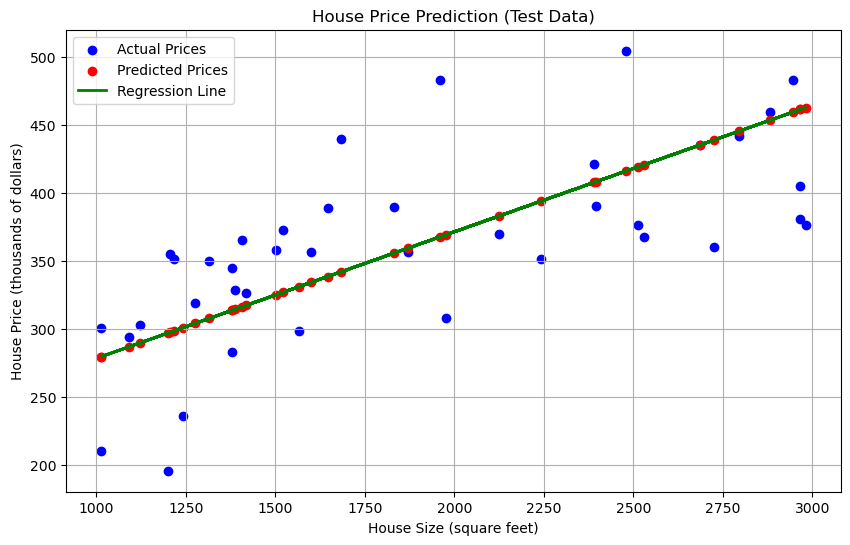

In [121]:
# Plot the original data points
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')

# Plot the predicted data points
plt.scatter(X_test, y_pred, color='red', label='Predicted Prices')

# Plot the regression line
plt.plot(X_test, y_pred, color='green', linewidth=2, label='Regression Line')

plt.title('House Price Prediction (Test Data)')
plt.xlabel('House Size (square feet)')
plt.ylabel('House Price (thousands of dollars)')
plt.legend()
plt.grid(True)
plt.show()

In [123]:
def plot_confusion_matrix(y_test, y_pred):
    # Calcola la confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Crea una heatmap della confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"], cbar=False)
    
    # Aggiungi etichette e titolo
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    
    plt.show()

In [124]:
if task == 'classification':
    print(confusion_matrix(y_test,y_pred))
    plot_confusion_matrix(y_test,y_pred)


## Step 8: Use the model to make new predictions

Now that we have a trained model, we can use it to predict the price of houses with sizes that weren't in our original dataset.

In [125]:
# Load model
# collect real world set of input
# Make predictions API vs Caricamento backend (amazon sagemaker, cloud service)
# REAL TIME vs Batch
#make vs by  (modelli black box già pronti - poi ci sarà la possibilità di creare i modelli dell'utente)

# Create some new house sizes that we want to predict prices for
new_house_sizes = np.array([[1500], [2000], [2500]])

# Use our model to predict the prices
predicted_prices = model.predict(new_house_sizes)

# Display the results
for size, price in zip(new_house_sizes.flatten(), predicted_prices):
    print(f"A house with {size} square feet is predicted to cost ${price:.2f} thousand")

A house with 1500 square feet is predicted to cost $324.86 thousand
A house with 2000 square feet is predicted to cost $371.44 thousand
A house with 2500 square feet is predicted to cost $418.01 thousand


/opt/miniconda3/envs/ds_lecture_1/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### What are Overfitting and Underfitting?

When training machine learning models, we face two common challenges:

1. **Underfitting**: The model is too simple and fails to capture the underlying pattern in the data.
2. **Overfitting**: The model is too complex and fits the training data too closely, capturing noise instead of the true underlying relationship.

Let's visualize these concepts using our house price dataset!

**fare focus su pipeline**

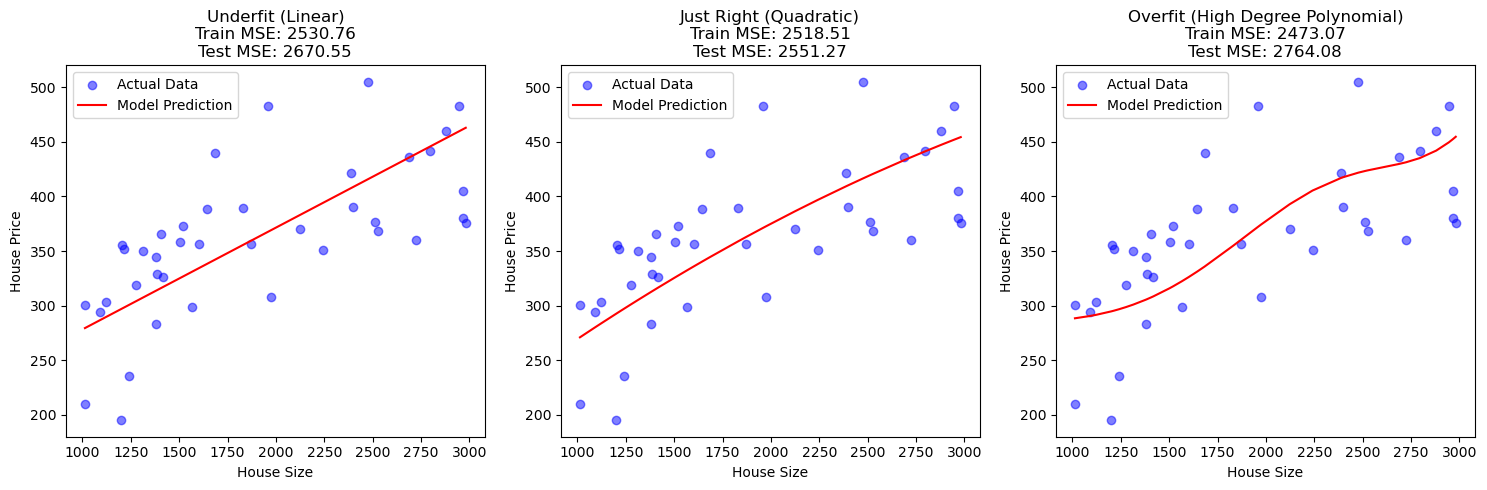

In [126]:
# Prepare the data
X = data[['Size']]
y = data['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create models of varying complexity
models = [
    ('Underfit (Linear)', LinearRegression()),
    ('Just Right (Quadratic)', make_pipeline(PolynomialFeatures(2), LinearRegression())),
    ('Overfit (High Degree Polynomial)', make_pipeline(PolynomialFeatures(10), LinearRegression()))
]

# Visualize different model complexities
plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models, 1):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    # Plot
    plt.subplot(1, 3, i)
    
    # Sort X for smooth curve plotting
    sort_axis = np.argsort(X_test.values.flatten())
    X_test_sorted = X_test.values[sort_axis]
    y_test_sorted = y_test.values[sort_axis]
    y_pred_sorted = y_test_pred[sort_axis]
    
    # Scatter plot of actual data
    plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data')
    
    # Plot the model's predictions
    plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Model Prediction')
    
    plt.title(f'{name}\nTrain MSE: {train_mse:.2f}\nTest MSE: {test_mse:.2f}')
    plt.xlabel('House Size')
    plt.ylabel('House Price')
    plt.legend()

plt.tight_layout()
plt.show()

### `make_pipeline`
La funzione make_pipeline in **scikit-learn** è un modo semplice per creare una **pipeline** che concatena insieme più passi di trasformazione e un modello di apprendimento automatico (come una regressione o una classificazione). La pipeline consente di eseguire le trasformazioni sui dati e applicare il modello in un flusso continuo senza bisogno di eseguire ogni passo separatamente.

  

**Come funziona make_pipeline:**

1. **Crea una sequenza di trasformazioni e modelli**:

• La funzione accetta una sequenza di tuple. Ogni tupla contiene: (es. `('Just Right (Quadratic)', make_pipeline(PolynomialFeatures(2), LinearRegression())),`

• Un nome per il passo (stringa).

• Un oggetto di trasformazione o modello (es. StandardScaler(), PolynomialFeatures(), LinearRegression()).

2. **Automatizza il processo di preprocessing e allenamento**:

• La pipeline permette di eseguire in sequenza i vari passaggi di preprocessing (ad esempio, normalizzazione dei dati) e applicare il modello senza ripetere manualmente ogni passo.

Provare [claude](https://claude.ai/login?returnTo=%2F%3F) per lo studio

## Bonus during the lesson in case of available time

Implement classification on titanic dataset with sklearn NaiveBayesClassifier(probabilità condizionata di bayes) or LogisticRegression(vedere formule su wikipedia, prevediamo un valore soglia, tutto quello che è sopra diventa 1 tutto quello che è sotto diventa 1)

## Conclusion

Congratulations! You've just built and trained your first machine learning model using linear regression. Here's what we learned:

1. How to prepare and visualize data
2. How to split data into training and testing sets
3. How to create and train a linear regression model
4. How to evaluate the model's performance
5. How to use the model to make new predictions
6. How to qualitatively assess if we are overfitting or underfitting

This is just the beginning of your machine learning journey. As you progress, you can explore more complex algorithms and datasets!

## Homework Exercise

Start from this notebook.

Assume house price depends not only on size, but also on number of windows.

n_windows = np.random.randint(3,8,n_samples)

house_prices = 100 + 0.2 * house_sizes - 0.00003 * house_sizes**2 + np.random.normal(0, 50, n_samples) + 15*n_windows

Try:
1) change the initial data, but keep using only house_sizes as regressor. What has changed?
2) adapt the notebook to using both house_sizes and n_windows as regressors. What has changed?
3) come up with a good way to visualize linear regression outputs with 2 regressors (Visualizzazione di 3 dimensioni)


